Mounted at /content/drive
Device: cpu

Dataset split:
Train: 219
Validation: 47
Test: 48

Leakage check: PASSED


Epoch 1/15:   0%|          | 0/14 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/15: 100%|██████████| 14/14 [05:31<00:00, 23.70s/it, loss=0.375]


Epoch 01 | Train Loss: 0.322745 | Val Loss: 0.314272


Epoch 2/15: 100%|██████████| 14/14 [04:54<00:00, 21.07s/it, loss=0.354]


Epoch 02 | Train Loss: 0.318655 | Val Loss: 0.306473


...

Epoch 13 | Train Loss: 0.197529 | Val Loss: 0.184949


Epoch 14/15: 100%|██████████| 14/14 [04:51<00:00, 20.81s/it, loss=0.199]


Epoch 14 | Train Loss: 0.196482 | Val Loss: 0.182466


Epoch 15/15: 100%|██████████| 14/14 [05:03<00:00, 21.69s/it, loss=0.191]


Epoch 15 | Train Loss: 0.196665 | Val Loss: 0.179210


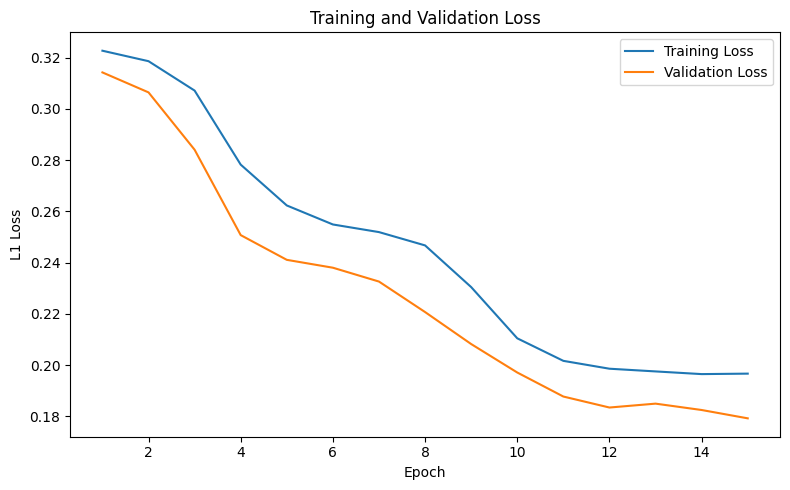


Validation outputs saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Learning_Based_Model/validation_outputs
Number of validation samples saved: 10


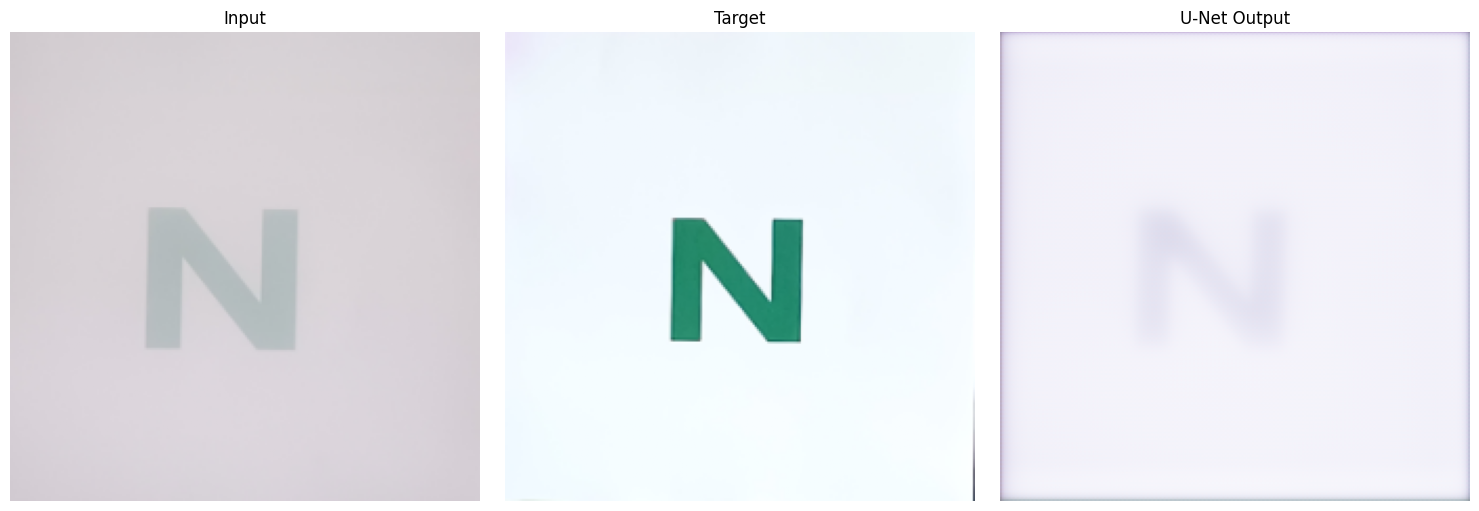



LEARNING-BASED APPROACH COMPLETE

Model: Supervised U-Net
Training samples: 219
Validation samples: 47
Test samples: 48
Best validation loss: 0.17920987593366744

Saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Learning_Based_Model/best_unet_model.pth
/content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Learning_Based_Model/training_history.csv
/content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Learning_Based_Model/training_validation_curve.png
/content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Learning_Based_Model/validation_outputs
/content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Learning_Based_Model/validation_output_visualization.png


In [1]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from google.colab import drive
drive.mount("/content/drive")


PROJECT_DIR = Path(
    "/content/drive/MyDrive/Underwater-Image-Data-set-main"
)

V1_DIR = PROJECT_DIR / "Dataset_V1"

MODEL_DIR = V1_DIR / "Learning_Based_Model"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_OUTPUT_DIR = MODEL_DIR / "validation_outputs"

TRAIN_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


split_file = (
    V1_DIR /
    "Dataset_V1_splits.csv"
)

splits = pd.read_csv(
    split_file
)

train_df = splits[
    splits["split"] == "train"
].copy()

val_df = splits[
    splits["split"] == "validation"
].copy()

test_df = splits[
    splits["split"] == "test"
].copy()

print("\nDataset split:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


assert set(
    train_df["sample_id"]
).isdisjoint(
    set(val_df["sample_id"])
)

assert set(
    train_df["sample_id"]
).isdisjoint(
    set(test_df["sample_id"])
)

assert set(
    val_df["sample_id"]
).isdisjoint(
    set(test_df["sample_id"])
)

print("\nLeakage check: PASSED")


IMAGE_SIZE = 224


class UnderwaterDataset(Dataset):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[index]

        input_img = cv2.imread(
            str(row["input"])
        )

        target_img = cv2.imread(
            str(row["target"])
        )

        if input_img is None:
            raise ValueError(
                f"Could not read input: {row['input']}"
            )

        if target_img is None:
            raise ValueError(
                f"Could not read target: {row['target']}"
            )

        input_img = cv2.cvtColor(
            input_img,
            cv2.COLOR_BGR2RGB
        )

        target_img = cv2.cvtColor(
            target_img,
            cv2.COLOR_BGR2RGB
        )

        input_img = cv2.resize(
            input_img,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        target_img = cv2.resize(
            target_img,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        input_img = (
            input_img.astype(np.float32)
            / 255.0
        )

        target_img = (
            target_img.astype(np.float32)
            / 255.0
        )

        input_img = torch.from_numpy(
            input_img
        ).permute(
            2, 0, 1
        )

        target_img = torch.from_numpy(
            target_img
        ).permute(
            2, 0, 1
        )

        return (
            input_img,
            target_img,
            row["sample_id"]
        )


train_dataset = UnderwaterDataset(
    train_df
)

val_dataset = UnderwaterDataset(
    val_df
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.block(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.enc1 = DoubleConv(
            3,
            32
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool = nn.MaxPool2d(
            2
        )

        self.bottleneck = DoubleConv(
            128,
            256
        )

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        self.output = nn.Conv2d(
            32,
            3,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        b = self.bottleneck(
            self.pool(e3)
        )

        d3 = self.up3(b)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return torch.sigmoid(
            self.output(d1)
        )


model = UNet().to(
    DEVICE
)

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

EPOCHS = 15


history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": []
}


best_val_loss = float("inf")

best_model_file = (
    MODEL_DIR /
    "best_unet_model.pth"
)


for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()

    train_loss = 0.0

    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS}"
    )

    for inputs, targets, _ in train_progress:

        inputs = inputs.to(
            DEVICE,
            non_blocking=True
        )

        targets = targets.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(
            inputs
        )

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item()
            * inputs.size(0)
        )

        train_progress.set_postfix(
            loss=loss.item()
        )

    train_loss /= len(
        train_dataset
    )


    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for inputs, targets, _ in val_loader:

            inputs = inputs.to(
                DEVICE,
                non_blocking=True
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(
                inputs
            )

            loss = criterion(
                outputs,
                targets
            )

            val_loss += (
                loss.item()
                * inputs.size(0)
            )

    val_loss /= len(
        val_dataset
    )


    history["epoch"].append(
        epoch
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_file
        )


history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    MODEL_DIR /
    "training_history.csv",
    index=False
)


with open(
    MODEL_DIR /
    "training_config.json",
    "w"
) as f:

    json.dump(
        {
            "model": "Supervised U-Net",
            "image_size": IMAGE_SIZE,
            "batch_size": 16,
            "epochs": EPOCHS,
            "learning_rate": 1e-4,
            "loss": "L1",
            "optimizer": "Adam",
            "dataset": "Dataset V1",
            "split": "Frozen Dataset V1 split",
            "device": str(DEVICE)
        },
        f,
        indent=4
    )


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    MODEL_DIR /
    "training_validation_curve.png",
    dpi=300
)

plt.show()


model.load_state_dict(
    torch.load(
        best_model_file,
        map_location=DEVICE
    )
)

model.eval()


num_saved = min(
    10,
    len(val_dataset)
)

saved_samples = []

with torch.no_grad():

    for i in range(num_saved):

        input_img, target_img, sample_id = (
            val_dataset[i]
        )

        input_tensor = (
            input_img
            .unsqueeze(0)
            .to(DEVICE)
        )

        output = model(
            input_tensor
        )

        output_img = (
            output.squeeze(0)
            .cpu()
            .numpy()
            .transpose(1, 2, 0)
        )

        input_np = (
            input_img
            .numpy()
            .transpose(1, 2, 0)
        )

        target_np = (
            target_img
            .numpy()
            .transpose(1, 2, 0)
        )

        output_img = np.clip(
            output_img,
            0,
            1
        )

        input_uint8 = (
            input_np * 255
        ).astype(np.uint8)

        target_uint8 = (
            target_np * 255
        ).astype(np.uint8)

        output_uint8 = (
            output_img * 255
        ).astype(np.uint8)

        cv2.imwrite(
            str(
                TRAIN_OUTPUT_DIR /
                f"{sample_id}_input.png"
            ),
            cv2.cvtColor(
                input_uint8,
                cv2.COLOR_RGB2BGR
            )
        )

        cv2.imwrite(
            str(
                TRAIN_OUTPUT_DIR /
                f"{sample_id}_target.png"
            ),
            cv2.cvtColor(
                target_uint8,
                cv2.COLOR_RGB2BGR
            )
        )

        cv2.imwrite(
            str(
                TRAIN_OUTPUT_DIR /
                f"{sample_id}_output.png"
            ),
            cv2.cvtColor(
                output_uint8,
                cv2.COLOR_RGB2BGR
            )
        )

        saved_samples.append(
            str(sample_id)
        )


print("\nValidation outputs saved:")
print(
    TRAIN_OUTPUT_DIR
)

print(
    "Number of validation samples saved:",
    len(saved_samples)
)


sample = val_dataset[0]

input_img, target_img, sample_id = sample

with torch.no_grad():

    output = model(
        input_img
        .unsqueeze(0)
        .to(DEVICE)
    )

output_img = (
    output.squeeze(0)
    .cpu()
    .numpy()
    .transpose(1, 2, 0)
)

input_np = (
    input_img
    .numpy()
    .transpose(1, 2, 0)
)

target_np = (
    target_img
    .numpy()
    .transpose(1, 2, 0)
)

plt.figure(
    figsize=(15, 5)
)

plt.subplot(1, 3, 1)
plt.imshow(input_np)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(target_np)
plt.title("Target")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    np.clip(
        output_img,
        0,
        1
    )
)
plt.title("U-Net Output")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    MODEL_DIR /
    "validation_output_visualization.png",
    dpi=300
)

plt.show()


print("\n")
print("=" * 70)
print("LEARNING-BASED APPROACH COMPLETE")
print("=" * 70)

print("\nModel: Supervised U-Net")
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_df))
print("Best validation loss:", best_val_loss)

print("\nSaved:")
print(
    MODEL_DIR /
    "best_unet_model.pth"
)

print(
    MODEL_DIR /
    "training_history.csv"
)

print(
    MODEL_DIR /
    "training_validation_curve.png"
)

print(
    TRAIN_OUTPUT_DIR
)

print(
    MODEL_DIR /
    "validation_output_visualization.png"
)